In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class SalesDataAnalyzer:
    
    def __init__(self):
        self.df = None
        self.original_df = None
    
    def __del__(self):
        print("\nSalesDataAnalyzer object deleted.")
    
    # ------------------------------------------------
    # 1. LOAD DATA
    # ------------------------------------------------
    def load_data(self, file_path):
        try:
            self.df = pd.read_csv(file_path)
            self.original_df = self.df.copy()
            
            print("\nData loaded successfully!")
            print(f"Dataset Shape: {self.df.shape}")
            
        except FileNotFoundError:
            print("\nError: File not found.")
        except Exception as e:
            print(f"\nError: {e}")
    
    
    # ------------------------------------------------
    # 2. EXPLORE DATA
    # ------------------------------------------------
    def explore_data(self):
        
        if self.df is None:
            print("\nPlease load the dataset first!")
            return
        
        while True:
            print("\n========== EXPLORE DATA ==========")
            print("1. Display first 5 rows")
            print("2. Display last 5 rows")
            print("3. Display column names")
            print("4. Display data types")
            print("5. Display basic info")
            print("6. Display dataset shape")
            print("7. Back")
            
            choice = input("\nEnter your choice: ")
            
            if choice == "1":
                print("\nFirst 5 Rows:")
                display(self.df.head())
                
            elif choice == "2":
                print("\nLast 5 Rows:")
                display(self.df.tail())
                
            elif choice == "3":
                print("\nColumn Names:")
                print(self.df.columns.tolist())
                
            elif choice == "4":
                print("\nData Types:")
                print(self.df.dtypes)
                
            elif choice == "5":
                print("\nDataset Information:")
                self.df.info()
                
            elif choice == "6":
                print(f"\nDataset Shape: {self.df.shape}")
                
            elif choice == "7":
                break
                
            else:
                print("Invalid choice!")
    
    
    # ------------------------------------------------
    # 3. DATAFRAME OPERATIONS
    # ------------------------------------------------
    def dataframe_operations(self):
        
        if self.df is None:
            print("\nPlease load the dataset first!")
            return
        
        while True:
            print("\n====== DATAFRAME OPERATIONS ======")
            print("1. Add new column")
            print("2. Perform mathematical operation")
            print("3. Combine DataFrames")
            print("4. Split DataFrame")
            print("5. Sort DataFrame")
            print("6. Filter DataFrame")
            print("7. Back")
            
            choice = input("\nEnter your choice: ")
            
            if choice == "1":
                column_name = input("Enter new column name: ")
                value = input("Enter value: ")
                
                self.df[column_name] = value
                
                print(f"\nColumn '{column_name}' added successfully!")
                display(self.df.head())
            
            
            elif choice == "2":
                
                numeric_cols = self.df.select_dtypes(include=np.number).columns.tolist()
                
                if len(numeric_cols) == 0:
                    print("No numeric columns available!")
                else:
                    print("\nNumeric Columns:", numeric_cols)
                    
                    col = input("Enter column name: ")
                    
                    if col in self.df.columns:
                        
                        print("1. Add")
                        print("2. Subtract")
                        print("3. Multiply")
                        print("4. Divide")
                        
                        operation = input("Choose operation: ")
                        value = float(input("Enter value: "))
                        
                        if operation == "1":
                            result = self.df[col] + value
                        elif operation == "2":
                            result = self.df[col] - value
                        elif operation == "3":
                            result = self.df[col] * value
                        elif operation == "4":
                            result = self.df[col] / value
                        else:
                            print("Invalid operation!")
                            continue
                        
                        print("\nResult:")
                        print(result.head())
                    
                    else:
                        print("Column not found!")
            
            
            elif choice == "3":
                print("\nCombining DataFrame with itself as demonstration.")
                
                combined_df = pd.concat([self.df, self.df], ignore_index=True)
                
                print("Combined DataFrame:")
                display(combined_df.head())
            
            
            elif choice == "4":
                
                column = input("Enter column name for splitting: ")
                
                if column in self.df.columns:
                    unique_values = self.df[column].unique()
                    
                    print("\nUnique values:", unique_values)
                    
                    value = input("Enter value to create split DataFrame: ")
                    
                    split_df = self.df[
                        self.df[column].astype(str) == value
                    ]
                    
                    display(split_df)
                    
                else:
                    print("Column not found!")
            
            
            elif choice == "5":
                
                column = input("Enter column name for sorting: ")
                
                if column in self.df.columns:
                    
                    order = input("Ascending? (yes/no): ").lower()
                    
                    ascending = True if order == "yes" else False
                    
                    sorted_df = self.df.sort_values(
                        by=column,
                        ascending=ascending
                    )
                    
                    display(sorted_df.head(10))
                    
                else:
                    print("Column not found!")
            
            
            elif choice == "6":
                
                column = input("Enter column name: ")
                
                if column in self.df.columns:
                    
                    condition = input("Enter value to filter: ")
                    
                    filtered_df = self.df[
                        self.df[column].astype(str) == condition
                    ]
                    
                    display(filtered_df)
                    
                else:
                    print("Column not found!")
            
            
            elif choice == "7":
                break
                
            else:
                print("Invalid choice!")
    
    
    # ------------------------------------------------
    # 4. HANDLE MISSING DATA
    # ------------------------------------------------
    def handle_missing_data(self):
        
        if self.df is None:
            print("\nPlease load the dataset first!")
            return
        
        while True:
            print("\n====== HANDLE MISSING DATA ======")
            print("1. Display rows with missing values")
            print("2. Fill missing values with mean")
            print("3. Drop rows with missing values")
            print("4. Replace missing values with specific value")
            print("5. Back")
            
            choice = input("\nEnter your choice: ")
            
            if choice == "1":
                
                missing_df = self.df[self.df.isnull().any(axis=1)]
                
                if missing_df.empty:
                    print("\nNo missing values found in the dataset!")
                else:
                    display(missing_df)
            
            
            elif choice == "2":
                
                numeric_cols = self.df.select_dtypes(
                    include=np.number
                ).columns
                
                self.df[numeric_cols] = self.df[numeric_cols].fillna(
                    self.df[numeric_cols].mean()
                )
                
                print("\nMissing numeric values filled with mean!")
            
            
            elif choice == "3":
                
                before = self.df.shape[0]
                
                self.df.dropna(inplace=True)
                
                after = self.df.shape[0]
                
                print(f"\nRows before: {before}")
                print(f"Rows after: {after}")
                print("Rows with missing values removed!")
            
            
            elif choice == "4":
                
                value = input("Enter replacement value: ")
                
                self.df = self.df.fillna(value)
                
                print("\nMissing values replaced successfully!")
            
            
            elif choice == "5":
                break
                
            else:
                print("Invalid choice!")
    
    
    # ------------------------------------------------
    # 5. DESCRIPTIVE STATISTICS
    # ------------------------------------------------
    def descriptive_statistics(self):
        
        if self.df is None:
            print("\nPlease load the dataset first!")
            return
        
        print("\n====== DESCRIPTIVE STATISTICS ======")
        
        print("\nDataset Summary:")
        display(self.df.describe(include="all"))
        
        numeric_cols = self.df.select_dtypes(
            include=np.number
        ).columns.tolist()
        
        if len(numeric_cols) == 0:
            print("No numeric columns found!")
            return
        
        print("\nAvailable Numeric Columns:")
        print(numeric_cols)
        
        column = input("\nEnter column name: ")
        
        if column not in self.df.columns:
            print("Column not found!")
            return
        
        if not pd.api.types.is_numeric_dtype(self.df[column]):
            print("Selected column is not numeric!")
            return
        
        print(f"\nStatistics for {column}:")
        print("Sum:", self.df[column].sum())
        print("Mean:", self.df[column].mean())
        print("Median:", self.df[column].median())
        print("Standard Deviation:", self.df[column].std())
        print("Variance:", self.df[column].var())
        print("Minimum:", self.df[column].min())
        print("Maximum:", self.df[column].max())
        print("25% Quartile:", self.df[column].quantile(0.25))
        print("50% Quartile:", self.df[column].quantile(0.50))
        print("75% Quartile:", self.df[column].quantile(0.75))
    
    
    # ------------------------------------------------
    # 6. DATA VISUALIZATION
    # ------------------------------------------------
    def visualize_data(self):
        
        if self.df is None:
            print("\nPlease load the dataset first!")
            return
        
        while True:
            
            print("\n====== DATA VISUALIZATION ======")
            print("1. Bar Chart")
            print("2. Line Chart")
            print("3. Scatter Plot")
            print("4. Histogram")
            print("5. Box Plot")
            print("6. Heatmap")
            print("7. Subplots")
            print("8. Back")
            
            choice = input("\nEnter your choice: ")
            
            # ---------------- BAR CHART ----------------
            if choice == "1":
                
                x = input("Enter X-axis column: ")
                y = input("Enter Y-axis column: ")
                
                if x in self.df.columns and y in self.df.columns:
                    
                    plt.figure(figsize=(10, 6))
                    
                    sns.barplot(
                        data=self.df,
                        x=x,
                        y=y,
                        estimator=np.sum
                    )
                    
                    plt.title(f"{y} by {x}")
                    plt.xticks(rotation=45)
                    plt.tight_layout()
                    plt.show()
                
                
            # ---------------- LINE CHART ----------------
            elif choice == "2":
                
                x = input("Enter X-axis column: ")
                y = input("Enter Y-axis column: ")
                
                if x in self.df.columns and y in self.df.columns:
                    
                    plt.figure(figsize=(10, 6))
                    
                    plt.plot(
                        self.df[x],
                        self.df[y],
                        marker="o"
                    )
                    
                    plt.xlabel(x)
                    plt.ylabel(y)
                    plt.title(f"{y} vs {x}")
                    plt.xticks(rotation=45)
                    plt.grid()
                    plt.tight_layout()
                    plt.show()
            
            
            # ---------------- SCATTER PLOT ----------------
            elif choice == "3":
                
                x = input("Enter X-axis numeric column: ")
                y = input("Enter Y-axis numeric column: ")
                
                if x in self.df.columns and y in self.df.columns:
                    
                    plt.figure(figsize=(8, 6))
                    
                    sns.scatterplot(
                        data=self.df,
                        x=x,
                        y=y
                    )
                    
                    plt.title(f"{y} vs {x}")
                    plt.tight_layout()
                    plt.show()
            
            
            # ---------------- HISTOGRAM ----------------
            elif choice == "4":
                
                column = input("Enter numeric column: ")
                
                if column in self.df.columns:
                    
                    plt.figure(figsize=(8, 6))
                    
                    sns.histplot(
                        self.df[column],
                        kde=True
                    )
                    
                    plt.title(f"Distribution of {column}")
                    plt.tight_layout()
                    plt.show()
            
            
            # ---------------- BOX PLOT ----------------
            elif choice == "5":
                
                column = input("Enter numeric column: ")
                
                if column in self.df.columns:
                    
                    plt.figure(figsize=(8, 6))
                    
                    sns.boxplot(
                        y=self.df[column]
                    )
                    
                    plt.title(f"Box Plot of {column}")
                    plt.tight_layout()
                    plt.show()
            
            
            # ---------------- HEATMAP ----------------
            elif choice == "6":
                
                numeric_df = self.df.select_dtypes(
                    include=np.number
                )
                
                if numeric_df.shape[1] < 2:
                    print("At least 2 numeric columns are required!")
                else:
                    
                    plt.figure(figsize=(10, 6))
                    
                    sns.heatmap(
                        numeric_df.corr(),
                        annot=True,
                        cmap="coolwarm",
                        fmt=".2f"
                    )
                    
                    plt.title("Correlation Heatmap")
                    plt.tight_layout()
                    plt.show()
            
            
            # ---------------- SUBPLOTS ----------------
            elif choice == "7":
                
                numeric_cols = self.df.select_dtypes(
                    include=np.number
                ).columns.tolist()
                
                if len(numeric_cols) >= 2:
                    
                    col1 = numeric_cols[0]
                    col2 = numeric_cols[1]
                    
                    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
                    
                    axes[0].hist(self.df[col1])
                    axes[0].set_title(f"Histogram of {col1}")
                    
                    axes[1].boxplot(self.df[col2].dropna())
                    axes[1].set_title(f"Box Plot of {col2}")
                    
                    plt.tight_layout()
                    plt.show()
                
                else:
                    print("At least 2 numeric columns are required!")
            
            
            elif choice == "8":
                break
            
            else:
                print("Invalid choice!")
    
    
    # ------------------------------------------------
    # 7. SAVE VISUALIZATION
    # ------------------------------------------------
    def save_visualization(self):
        
        if self.df is None:
            print("\nPlease load the dataset first!")
            return
        
        numeric_cols = self.df.select_dtypes(
            include=np.number
        ).columns.tolist()
        
        if len(numeric_cols) == 0:
            print("No numeric columns available!")
            return
        
        print("\nAvailable numeric columns:")
        print(numeric_cols)
        
        column = input("Enter column for visualization: ")
        
        if column not in self.df.columns:
            print("Column not found!")
            return
        
        filename = input(
            "Enter file name (example: chart.png or chart.jpg): "
        )
        
        plt.figure(figsize=(8, 6))
        
        sns.histplot(
            self.df[column],
            kde=True
        )
        
        plt.title(f"Distribution of {column}")
        
        plt.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )
        
        plt.show()
        
        print(f"\nVisualization saved successfully as {filename}")
    
    
    # ------------------------------------------------
    # ADVANCED OPERATIONS
    # ------------------------------------------------
    def advanced_operations(self):
        
        if self.df is None:
            print("\nPlease load the dataset first!")
            return
        
        while True:
            
            print("\n====== ADVANCED OPERATIONS ======")
            print("1. Create Pivot Table")
            print("2. Re-index Dataset")
            print("3. GroupBy and Aggregation")
            print("4. Back")
            
            choice = input("\nEnter your choice: ")
            
            
            if choice == "1":
                
                index_col = input("Enter index column: ")
                value_col = input("Enter numeric value column: ")
                
                if index_col in self.df.columns and value_col in self.df.columns:
                    
                    pivot = pd.pivot_table(
                        self.df,
                        index=index_col,
                        values=value_col,
                        aggfunc="sum"
                    )
                    
                    print("\nPivot Table:")
                    display(pivot)
                
                else:
                    print("Invalid column name!")
            
            
            elif choice == "2":
                
                self.df.reset_index(
                    drop=True,
                    inplace=True
                )
                
                print("\nDataset re-indexed successfully!")
                display(self.df.head())
            
            
            elif choice == "3":
                
                group_col = input("Enter column for grouping: ")
                value_col = input("Enter numeric column: ")
                
                if group_col in self.df.columns and value_col in self.df.columns:
                    
                    result = self.df.groupby(
                        group_col
                    )[value_col].agg(
                        ["sum", "mean", "min", "max", "count"]
                    )
                    
                    print("\nGroupBy Result:")
                    display(result)
                
                else:
                    print("Invalid column name!")
            
            
            elif choice == "4":
                break
            
            else:
                print("Invalid choice!")
    
    
    # ------------------------------------------------
    # MAIN MENU
    # ------------------------------------------------
    def run(self):
        
        while True:
            
            print("\n" + "=" * 55)
            print("        DATA ANALYSIS & VISUALIZATION PROGRAM")
            print("=" * 55)
            
            print("1. Load Dataset")
            print("2. Explore Data")
            print("3. Perform DataFrame Operations")
            print("4. Handle Missing Data")
            print("5. Generate Descriptive Statistics")
            print("6. Data Visualization")
            print("7. Save Visualization")
            print("8. Advanced Operations")
            print("9. Exit")
            
            choice = input("\nEnter your choice: ")
            
            
            if choice == "1":
                
                file_path = input(
                    "Enter CSV file path (example: sales_data.csv): "
                )
                
                self.load_data(file_path)
            
            
            elif choice == "2":
                self.explore_data()
            
            
            elif choice == "3":
                self.dataframe_operations()
            
            
            elif choice == "4":
                self.handle_missing_data()
            
            
            elif choice == "5":
                self.descriptive_statistics()
            
            
            elif choice == "6":
                self.visualize_data()
            
            
            elif choice == "7":
                self.save_visualization()
            
            
            elif choice == "8":
                self.advanced_operations()
            
            
            elif choice == "9":
                
                print("\nThank you for using the program!")
                print("Program closed successfully.")
                
                break
            
            else:
                print("\nInvalid choice! Please try again.")


        DATA ANALYSIS & VISUALIZATION PROGRAM
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Advanced Operations
9. Exit



Enter your choice:  1
Enter CSV file path (example: sales_data.csv):  sales_data.csv



Data loaded successfully!
Dataset Shape: (1000, 14)

        DATA ANALYSIS & VISUALIZATION PROGRAM
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Advanced Operations
9. Exit



Enter your choice:  2



========== EXPLORE DATA ==========
1. Display first 5 rows
2. Display last 5 rows
3. Display column names
4. Display data types
5. Display basic info
6. Display dataset shape
7. Back


...

Enter column for visualization:  6


Column not found!

        DATA ANALYSIS & VISUALIZATION PROGRAM
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Advanced Operations
9. Exit



Enter your choice:  6



====== DATA VISUALIZATION ======
1. Bar Chart
2. Line Chart
3. Scatter Plot
4. Histogram
5. Box Plot
6. Heatmap
7. Subplots
8. Back



Enter your choice:  3
Enter X-axis numeric column:  Sales_Amount
Enter Y-axis numeric column:  Sale_Date


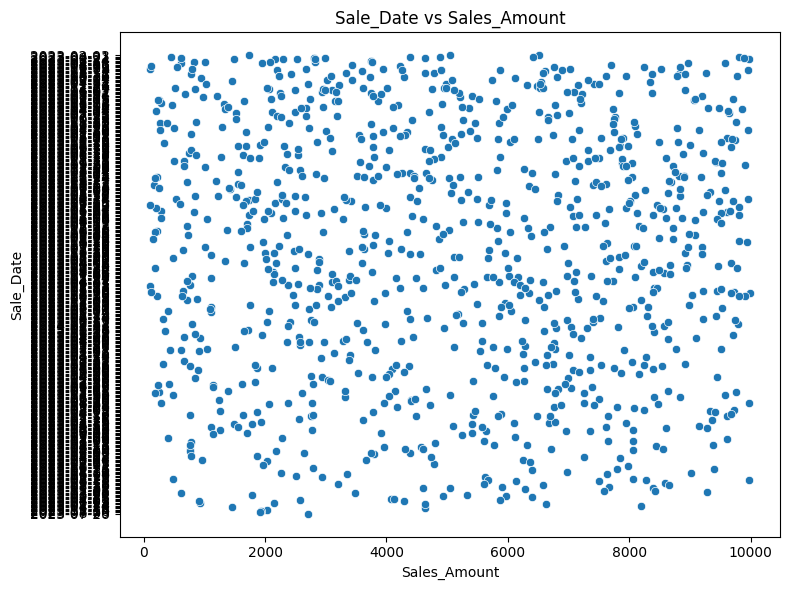


====== DATA VISUALIZATION ======
1. Bar Chart
2. Line Chart
3. Scatter Plot
4. Histogram
5. Box Plot
6. Heatmap
7. Subplots
8. Back



Enter your choice:  8



        DATA ANALYSIS & VISUALIZATION PROGRAM
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Advanced Operations
9. Exit



Enter your choice:  7



Available numeric columns:
['Product_ID', 'Sales_Amount', 'Quantity_Sold', 'Unit_Cost', 'Unit_Price', 'Discount']


Enter column for visualization:  Sales_Amount
Enter file name (example: chart.png or chart.jpg):  Scatter Plot.jpg


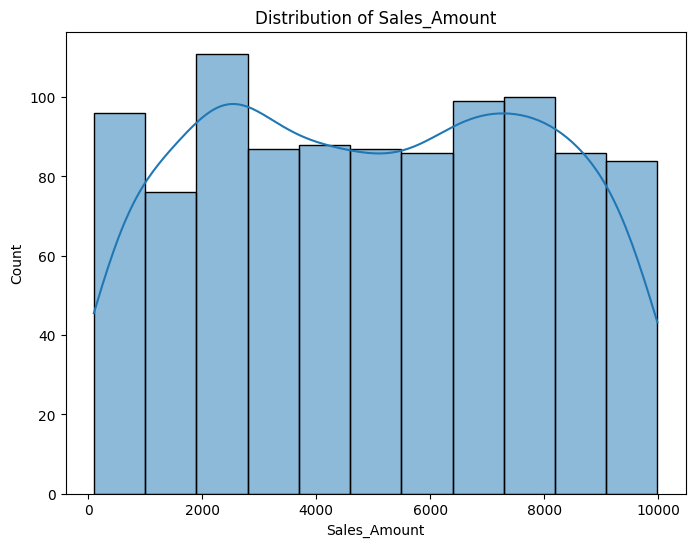


Visualization saved successfully as Scatter Plot.jpg

        DATA ANALYSIS & VISUALIZATION PROGRAM
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Advanced Operations
9. Exit



Enter your choice:  9



Thank you for using the program!
Program closed successfully.


In [3]:
analyzer = SalesDataAnalyzer()
analyzer.run()